In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys
sys.path.append('../')

from src.embedding_position import EmbeddingPosition
from src.embedding import Embedding

from src.trajectory_utils import reconstruct_trajectory_from_canonical_pieces

In [2]:
df = pd.read_csv('../data/toy_model/interim/longest_trajectory_only_persistent.csv')
df.head()
print(df[['x','y','z']].to_numpy().shape)

(997, 3)


In [3]:
emb = EmbeddingPosition(df,columns=[],columns_translated=['x','y','z'],ID_NAME='label')
K = 40
emb.make_embedding(K=K)
emb.make_cluster(10)
print(emb.flatten_embedding_matrix.shape)

(958, 120)


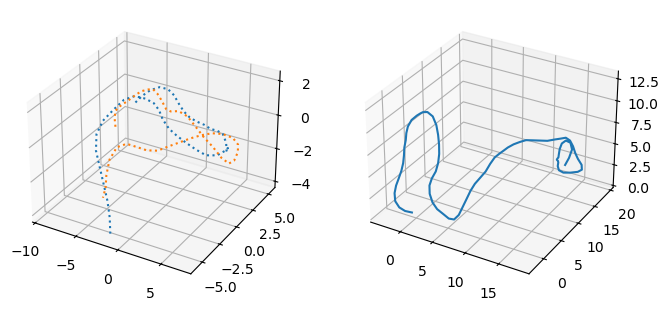

In [5]:
fig,ax  = plt.subplots(ncols= 2, subplot_kw={'projection':'3d'},figsize=(8,4))
I0 = 0
I1=I0 + 40

ax[0].plot(emb.flatten_embedding_matrix[I0][0::3],emb.flatten_embedding_matrix[I0][1::3],emb.flatten_embedding_matrix[I0][2::3],linestyle=':')
ax[0].plot(emb.flatten_embedding_matrix[I1][0::3],emb.flatten_embedding_matrix[I1][1::3],emb.flatten_embedding_matrix[I1][2::3],linestyle=':')

ax[1].plot(df['x'][I0:I1+K],df['y'][I0:I1+K],df['z'][I0:I1+K])
#ax.set_aspect('equal')

In [6]:
pieces = np.array([emb.flatten_embedding_matrix[I0],emb.flatten_embedding_matrix[I1]])

In [7]:
X = reconstruct_trajectory_from_canonical_pieces(pieces, K = K)
print(X.shape)

(79, 3)


In [9]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "notebook_connected"

# your params
I0 = 0
I1 = I0 + 40
# K must already be defined (as in your Matplotlib slice)

# convenience
v0 = emb.flatten_embedding_matrix[I0]
v1 = emb.flatten_embedding_matrix[I1]

x0, y0, z0 = v0[0::3], v0[1::3], v0[2::3]
x1, y1, z1 = v1[0::3], v1[1::3], v1[2::3]

# df['x','y','z'] slice (same as your code)
xs = df['x'].iloc[I0:I1+K].to_numpy()
ys = df['y'].iloc[I0:I1+K].to_numpy()
zs = df['z'].iloc[I0:I1+K].to_numpy()

xs1 = X[:,0]
ys1 = X[:,1]
zs1 = X[:,2]

fig = make_subplots(
    rows=1, cols=3,
    specs=[[{"type": "scene"}, {"type": "scene"},{"type": "scene"}]],
    horizontal_spacing=0.06
)

# left subplot: two dashed lines
fig.add_trace(
    go.Scatter3d(x=x0, y=y0, z=z0, mode="lines",
                 line=dict(width=3, dash="dot"),
                 name=f"emb[{I0}]",
                 hovertemplate="x=%{x:.3g}<br>y=%{y:.3g}<br>z=%{z:.3g}<extra></extra>"),
    row=1, col=1
)
fig.add_trace(
    go.Scatter3d(x=x1, y=y1, z=z1, mode="lines",
                 line=dict(width=3, dash="dot"),
                 name=f"emb[{I1}]",
                 hovertemplate="x=%{x:.3g}<br>y=%{y:.3g}<br>z=%{z:.3g}<extra></extra>"),
    row=1, col=1
)

# right subplot: continuous line
fig.add_trace(
    go.Scatter3d(x=xs, y=ys, z=zs, mode="lines",
                 line=dict(width=3),
                 name=f"df[{I0}:{I1}+K]",
                 hovertemplate="x=%{x:.3g}<br>y=%{y:.3g}<br>z=%{z:.3g}<extra></extra>"),
    row=1, col=2
)
fig.add_trace(
    go.Scatter3d(x=xs1, y=ys1, z=zs1, mode="lines",
                 line=dict(width=3),
                 name=f"df[{I0}:{I1}+K]",
                 hovertemplate="x=%{x:.3g}<br>y=%{y:.3g}<br>z=%{z:.3g}<extra></extra>"),
    row=1, col=3
)

# layout roughly equivalent to ax.set_aspect('equal')
fig.update_layout(
    margin=dict(l=0, r=0, t=0, b=0),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0.02),
    scene=dict(
        xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
        aspectmode="data"
    ),
    scene2=dict(
        xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
        aspectmode="data"
    )
)

fig.write_html("plot.html", include_plotlyjs="cdn")



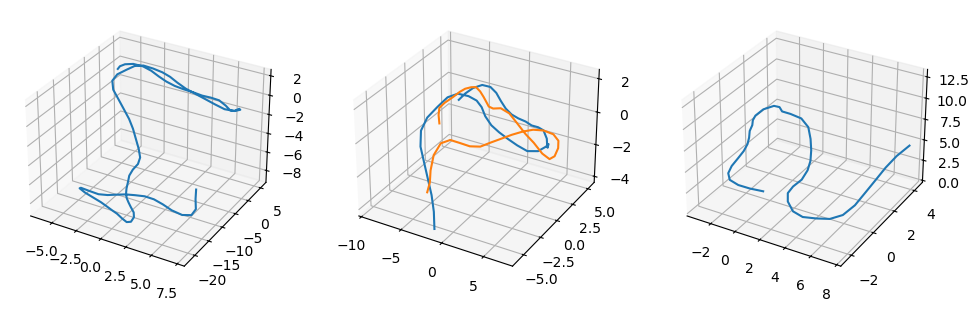

In [70]:
fig,ax  = plt.subplots(ncols=3,subplot_kw={'projection':'3d'},figsize=(12,4))
kmax = K#K+I0
ax[0].plot(X[:,0],X[:,1],X[:,2])
ax[1].plot(emb.flatten_embedding_matrix[I0][0::3],emb.flatten_embedding_matrix[I0][1::3],emb.flatten_embedding_matrix[I0][2::3],linestyle='-')
ax[1].plot(emb.flatten_embedding_matrix[I0+K][0::3],emb.flatten_embedding_matrix[I0+K][1::3],emb.flatten_embedding_matrix[I0+K][2::3],linestyle='-')
ax[2].plot(df['x'][I0:kmax],df['y'][I0:kmax],df['z'][I0:kmax])